In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits import mplot3d


In [12]:
def model(X, w, b):
    # y = np.dot(X, w) + b
    y = X @ w + b
    return y

In [13]:
def compute_cost(X, y, w, b): 
    # J function
    m = X.shape[0]
    e = y - model(X, w, b) # (w*x+b)
    total_cost = (1/(2* m)) * sum(e**2)
    return total_cost


In [14]:
X_train = np.array([[2104, 5, 1, 45], [1416, 3, 2, 40], [852, 2, 1, 35]])
y_train = np.array([460, 232, 178])

In [15]:
b_init = 785.1811367994083
w_init = np.array([ 0.39133535, 18.75376741, -53.36032453, -26.42131618])

In [16]:
# Compute and display cost using our pre-chosen optimal parameters. 
cost = compute_cost(X_train, y_train, w_init, b_init)
print(f'Cost at optimal w : {cost}')

Cost at optimal w : 1.5578904428966628e-12


In [17]:
def compute_gradient(X, y, w, b): 
    # Number of training examples
    m = X.shape[0] 
    e = model(X, w, b)- y
    dw = (1/m) * X.T @ e
    # dw = (1/m) * np.dot(e, X)
    db = (1/m) * e
    dw = sum(dw)
    db = sum(db)
    return dw, db

In [18]:
from copy import deepcopy
def gradient_descent(x, y, w_in = 0, b_in = 0, alpha = 1, num_iters = 100):
    
    w = deepcopy(w_in)
    b = deepcopy(b_in)
    p_history = [(w, b)]
    cost_history  = [compute_cost(x, y, w, b)] # J
    
    for i in range(num_iters):
        dw, db = compute_gradient(x, y, w, b)
        w = w - alpha * dw
        b = b - alpha * db
        p_history.append((w, b))
        cost_history.append(compute_cost(x, y, w, b))
        if i%100 == 0:
            print(f"Iteration {i:4}: Cost {cost_history[-1]:0.2e} ",
                  f"dj_dw: {dw}, dj_db: {db}  ",
                  f"w: {w}, b:{b}")

    return w, b, p_history, cost_history


In [19]:
# initialize parameters
initial_w = np.zeros_like(w_init)
initial_b = 0
# some gradient descent settings
iterations = 10000
tmp_alpha = 1.0e-7
# run gradient descent
w_final, b_final, p_history, cost_history = gradient_descent(X_train ,y_train, initial_w, initial_b, tmp_alpha, iterations)
print(f"(w,b) found by gradient descent: ({w_final},{b_final})")


Iteration    0: Cost 2.80e+04  dj_dw: -496223.99999999994, dj_db: -289.99999999999994   w: [0.0496224 0.0496224 0.0496224 0.0496224], b:2.8999999999999993e-05
Iteration  100: Cost 7.30e+02  dj_dw: -0.003184015693790343, dj_db: 5.3493507231996285   w: [0.19663734 0.19663734 0.19663734 0.19663734], b:6.300880107832637e-05
Iteration  200: Cost 7.30e+02  dj_dw: -0.0031838961343737537, dj_db: 5.3493450519337475   w: [0.19663737 0.19663737 0.19663737 0.19663737], b:9.515322485905451e-06
Iteration  300: Cost 7.30e+02  dj_dw: -0.0031838926548743984, dj_db: 5.34933938060477   w: [0.19663741 0.19663741 0.19663741 0.19663741], b:-4.397809939321588e-05
Iteration  400: Cost 7.30e+02  dj_dw: -0.003183889287669217, dj_db: 5.34933370928175   w: [0.19663744 0.19663744 0.19663744 0.19663744], b:-9.747146455907734e-05
Iteration  500: Cost 7.30e+02  dj_dw: -0.0031838859665640484, dj_db: 5.349328037964718   w: [0.19663747 0.19663747 0.19663747 0.19663747], b:-0.00015096477301173892
Iteration  600: Cost 7.3

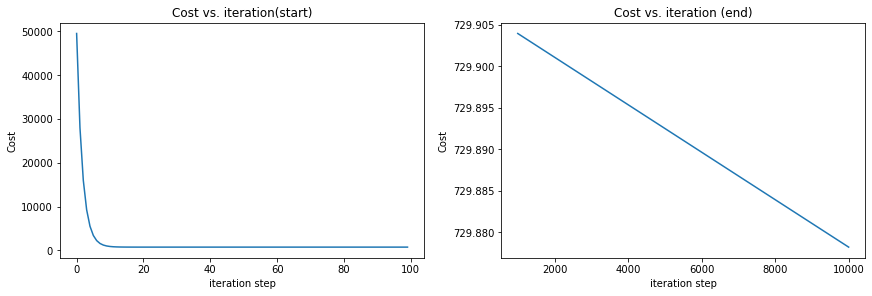

In [20]:
# plot cost versus iteration  
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12,4))
ax1.plot(cost_history[:100])
ax2.plot(1000 + np.arange(len(cost_history[1000:])), cost_history[1000:])
ax1.set_title("Cost vs. iteration(start)");  ax2.set_title("Cost vs. iteration (end)")
ax1.set_ylabel('Cost')            ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')  ;  ax2.set_xlabel('iteration step') 
plt.show()